In [1]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))

Load the trained sky model.

In [2]:
import os
import torch
import cv2
import matplotlib.pyplot as plt

from src.segmentation import load_segmentation_model, segment_image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_path = here() / "data" / "sky_segmentation_unet_model.pth"
model = load_segmentation_model(model_path, device)
print(f"Running on: {device}")

Running on: cpu


Segment all images in data/test_segmentation/images and show the masks.

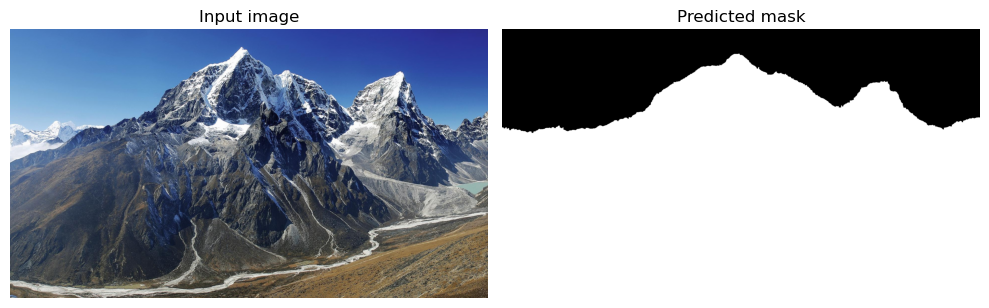

Saved mask to /home/admin/SkylineGeolocation/data/test_segmentation/predicted_masks/test_mask.png


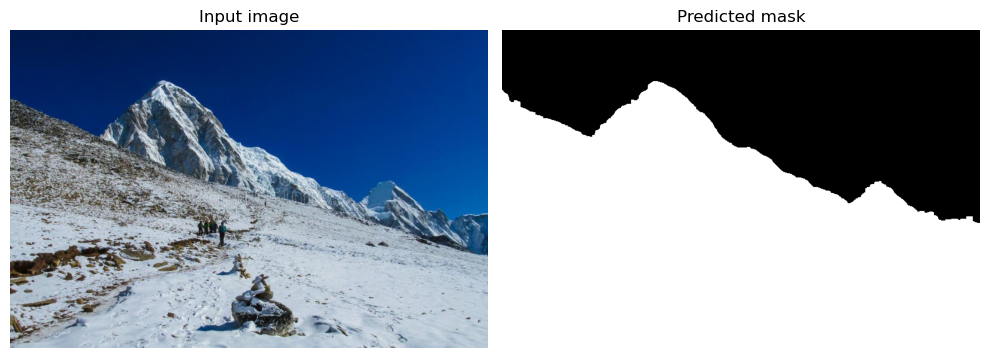

Saved mask to /home/admin/SkylineGeolocation/data/test_segmentation/predicted_masks/test2_mask.png


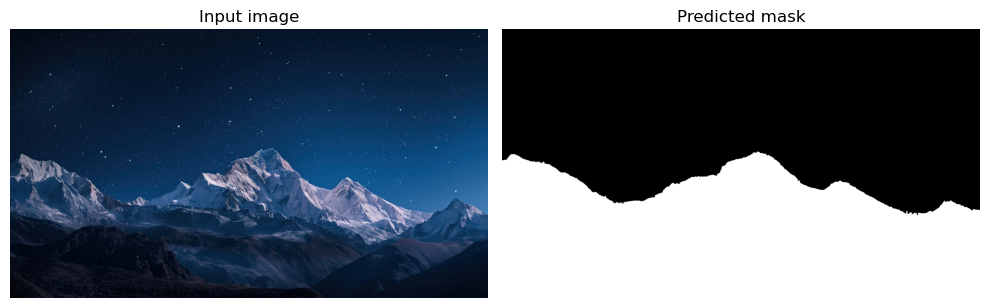

Saved mask to /home/admin/SkylineGeolocation/data/test_segmentation/predicted_masks/test3_mask.png


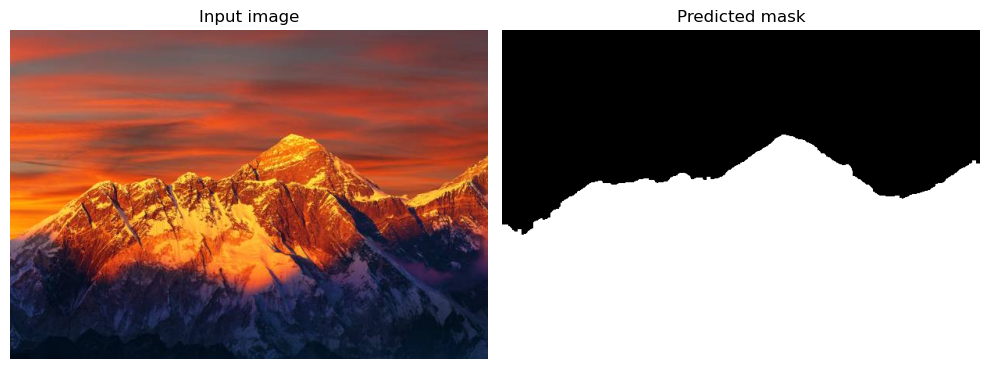

Saved mask to /home/admin/SkylineGeolocation/data/test_segmentation/predicted_masks/test4_mask.png


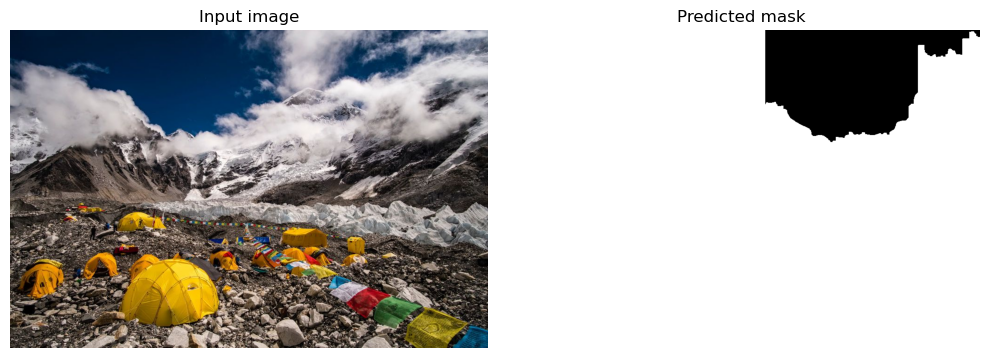

Saved mask to /home/admin/SkylineGeolocation/data/test_segmentation/predicted_masks/test5_mask.png


In [4]:
images_dir = here() / "data" / "test_segmentation" / "images"
masks_dir = here() / "data" / "test_segmentation" / "predicted_masks"
masks_dir.mkdir(parents=True, exist_ok=True)

image_paths = []
for file_name in sorted(os.listdir(images_dir)):
    if file_name.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
        image_paths.append(images_dir / file_name)

for image_path in image_paths:
    mask_path = masks_dir / f"{image_path.stem}_mask.png"
    segment_image(model, str(image_path), str(mask_path), device)

    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Saved mask to {mask_path}")